In [1]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('/kaggle/input/reliance/RELIANCE.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0
1,2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0
2,2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0
3,2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0
4,2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0
...,...,...,...,...,...,...,...
2629,2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0
2630,2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0
2631,2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0
2632,2019-09-13,1212.000000,1228.500000,1206.900024,1225.599976,1225.599976,5919260.0


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0
2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0
2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0
2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0
2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0
...,...,...,...,...,...,...
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0


In [4]:
print ("Rows     : " ,df.shape[0])
print ("Columns  : " ,df.shape[1])
print ("\nFeatures : \n" ,df.columns.tolist())
print ("\nMissing values :  ", df.isnull().any())
print ("\nUnique values :  \n",df.nunique())

Rows     :  2634
Columns  :  6

Features : 
 ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Missing values :   Open         False
High         False
Low          False
Close        False
Adj Close    False
Volume       False
dtype: bool

Unique values :  
 Open         2006
High         2167
Low          2193
Close        2398
Adj Close    2550
Volume       2631
dtype: int64


In [5]:
df['ma_20'] = df['Close'].rolling(window=20).mean()
df['std_20'] = df['Close'].rolling(20).std()
df['upper_bb'] = df['ma_20'] + (2 *df['std_20'] )
df['lower_bb'] = df['ma_20'] - (2 *df['std_20'] )

In [6]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume,ma_20,std_20,upper_bb,lower_bb
Date,,,,,,,,,,
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0,1243.182495,41.296740,1325.775975,1160.589016
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0,1247.284998,35.461594,1318.208185,1176.361810
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0,1249.697498,30.680246,1311.057990,1188.337005
2019-09-13,1212.000000,1228.500000,1206.900024,1225.599976,1225.599976,5919260.0,1247.239996,30.536044,1308.312084,1186.167909
2019-09-16,0.000000,1219.099976,1186.099976,1210.750000,1210.750000,9390427.0,1243.364996,29.970105,1303.305206,1183.424787


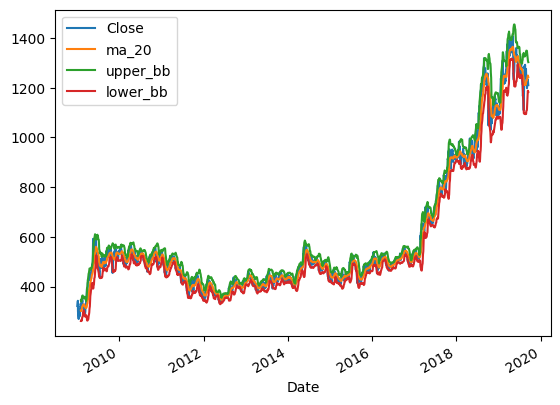

In [7]:
df[['Close','ma_20','upper_bb','lower_bb']].plot();

In [8]:
# ── RSI ───────────────────────────────────────────────────
class Indicator:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
    def rsi(self) -> None:
            delta = self.df['Close'].diff()
            gain  = delta.clip(lower=0)
            loss  = (-delta).clip(lower=0)
            avg_gain = gain.ewm(com=RSI_PERIOD - 1, adjust=False).mean()
            avg_loss = loss.ewm(com=RSI_PERIOD - 1, adjust=False).mean()
            rs = avg_gain / avg_loss.replace(0, np.nan)
            self.df["RSI"] = 100 - (100 / (1 + rs))
            self.df["RSI_overbought"] = RSI_OVERBOUGHT
            self.df["RSI_oversold"]   = RSI_OVERSOLD

In [9]:
RSI_PERIOD = 6
RSI_OVERBOUGHT = 70
RSI_OVERSOLD = 30

In [10]:
indicator = Indicator(df)

indicator.rsi()

df = indicator.df
df

,Open,High,Low,Close,Adj Close,Volume,ma_20,std_20,upper_bb,lower_bb,RSI,RSI_overbought,RSI_oversold
Date,,,,,,,,,,,,,
2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0,NaN,NaN,NaN,NaN,NaN,70,30
2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0,NaN,NaN,NaN,NaN,NaN,70,30
2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0,NaN,NaN,NaN,NaN,NaN,70,30
2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0,NaN,NaN,NaN,NaN,66.333406,70,30
2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0,NaN,NaN,NaN,NaN,59.609826,70,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0,1243.182495,41.296740,1325.775975,1160.589016,45.340855,70,30
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0,1247.284998,35.461594,1318.208185,1176.361810,53.421857,70,30
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0,1249.697498,30.680246,1311.057990,1188.337005,39.579561,70,30


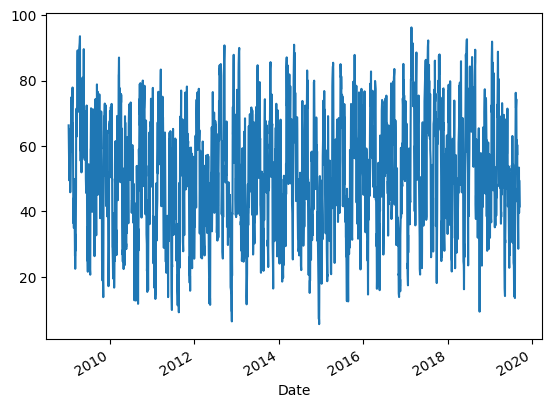

In [11]:
df['RSI'].plot();

In [12]:
conditions = [(df.RSI < 30) & (df.Close < df.lower_bb),
            (df.RSI > 70) & (df.Close > df.upper_bb)]

In [13]:
choices = ['Buy','Sell']

In [14]:
df['Signal'] = np.select(conditions,choices,default='Hold')
df.Signal = df.Signal.shift()

In [15]:
df.dropna()

,Open,High,Low,Close,Adj Close,Volume,ma_20,std_20,upper_bb,lower_bb,RSI,RSI_overbought,RSI_oversold,Signal
Date,,,,,,,,,,,,,,
2009-02-02,322.500000,338.200012,318.388000,320.000000,264.608765,21461864.0,303.644351,21.296192,346.236735,261.051967,62.453187,70,30,Hold
2009-02-03,322.500000,333.674988,318.263000,326.549988,270.024902,27643564.0,303.891850,21.543183,346.978216,260.805485,66.474921,70,30,Hold
2009-02-04,328.750000,334.375000,323.774994,326.875000,270.293671,15866960.0,303.162500,20.422041,344.006582,262.318418,66.687387,70,30,Hold
2009-02-05,332.250000,332.250000,317.787994,322.200012,266.427948,16426340.0,302.136250,18.778917,339.694084,264.578417,60.111707,70,30,Hold
2009-02-06,325.000000,337.500000,323.899994,336.212006,278.014465,17364252.0,303.937451,20.252071,344.441594,263.433309,70.554499,70,30,Hold
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0,1243.182495,41.296740,1325.775975,1160.589016,45.340855,70,30,Hold
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0,1247.284998,35.461594,1318.208185,1176.361810,53.421857,70,30,Hold
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0,1249.697498,30.680246,1311.057990,1188.337005,39.579561,70,30,Hold


In [16]:
df.tail(10)

,Open,High,Low,Close,Adj Close,Volume,ma_20,std_20,upper_bb,lower_bb,RSI,RSI_overbought,RSI_oversold,Signal
Date,,,,,,,,,,,,,,
2019-08-30,1245.500000,1254.400024,1221.000000,1248.550049,1248.550049,11308120.0,1227.922498,60.807874,1349.538245,1106.306750,46.997600,70,30,Hold
2019-09-03,1242.250000,1243.000000,1200.000000,1206.400024,1206.400024,8563009.0,1229.229999,60.004698,1349.239394,1109.220603,30.903487,70,30,Hold
2019-09-04,1200.550049,1205.250000,1186.050049,1201.150024,1201.150024,15063355.0,1230.070001,59.458463,1348.986927,1111.153075,29.398742,70,30,Hold
2019-09-05,1206.800049,1213.199951,1193.300049,1198.599976,1198.599976,10512763.0,1232.832501,56.423324,1345.679150,1119.985852,28.587406,70,30,Hold
2019-09-06,1203.000000,1229.000000,1195.250000,1222.500000,1222.500000,10600234.0,1237.542499,50.899429,1339.341356,1135.743642,45.502651,70,30,Hold
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0,1243.182495,41.296740,1325.775975,1160.589016,45.340855,70,30,Hold
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0,1247.284998,35.461594,1318.208185,1176.361810,53.421857,70,30,Hold
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0,1249.697498,30.680246,1311.057990,1188.337005,39.579561,70,30,Hold
2019-09-13,1212.000000,1228.500000,1206.900024,1225.599976,1225.599976,5919260.0,1247.239996,30.536044,1308.312084,1186.167909,49.530294,70,30,Hold


In [17]:
df['Signal'].value_counts()

Signal
Hold    2369
Sell     140
Buy      124
Name: count, dtype: int64

In [18]:
position= False
buydates,selldates = [],[]
buyprices, sellprices = [],[]

for index,row in df.iterrows():
    if not position and row['Signal']== 'Buy':
        buydates.append(index)
        buyprices.append(row.Open)
        position = True
    elif position and row['Signal'] == 'Sell':
        selldates.append(index)
        sellprices.append(row.Open)
        position=False

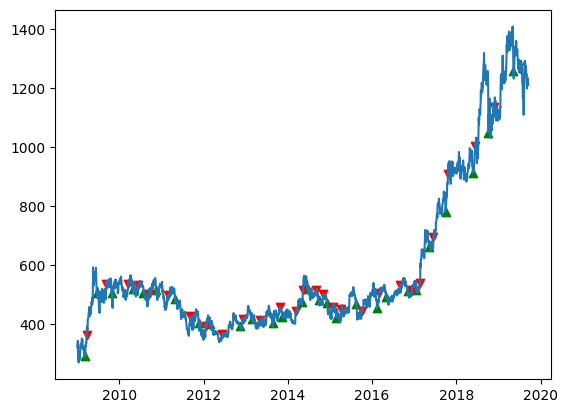

In [19]:
plt.plot(df.Close)
plt.scatter(df.loc[buydates].index, df.loc[buydates].Close,marker='^',c='g')
plt.scatter(df.loc[selldates].index, df.loc[selldates].Close,marker='v',c='r')


In [20]:
returns = pd.Series(
    [(sell - buy) / buy
     for sell, buy in zip(sellprices, buyprices)]
)
returns

0     0.283232
1     0.064165
2     0.048585
3     0.040234
4    -0.015946
5    -0.060392
6    -0.159778
7    -0.014120
8    -0.090045
9     0.053954
10    0.000120
11    0.157454
12    0.017884
13    0.075568
14   -0.019839
15    0.013784
16   -0.011690
17    0.047644
18   -0.033896
19    0.081486
20    0.069002
21   -0.003272
22    0.030285
23    0.044436
24    0.156678
25    0.079914
26    0.041382
dtype: float64

In [21]:
# 1. Total Return
print('Total Return',returns.sum(),'compounded return',(1 + returns).prod() - 1,'\n')
# 2. Win Rate
print('win_rate',(returns > 0).mean(),'\n')
# 3.Best / Worst Trade
print('Best / Worst Trade',returns.max(),returns.min())

Total Return 0.8968316133610483 compounded return 1.2231454511172495 

win_rate 0.6666666666666666 

Best / Worst Trade 0.28323186013550905 -0.15977822580645162
